In [1]:
#!pip install tensorflow --upgrade
#!apt-get update
#!apt-get install cuda-toolkit-11-0 cuda-toolkit-11-7 cuda-toolkit-11-8

In [2]:
#!pip install --upgrade --force-reinstall tensorflow

In [3]:
import os
os.environ['LD_LIBRARY_PATH'] = '/path/to/your/libraries'

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [5]:
from google.colab import files
files.upload()

Saving financial_regression.csv to financial_regression.csv


{'financial_regression.csv': b'date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,nasdaq close,nasdaq volume,nasdaq high-low,us_rates_%,CPI,usd_chf,eur_usd,GDP,silver open,silver high,silver low,silver close,silver volume,silver high-low,oil open,oil high,oil low,oil close,oil volume,oil high-low,platinum open,platinum high,platinum low,platinum close,platinum volume,platinum high-low,palladium open,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume\r\n2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.7199999999999989,46.26,46.52,46.22,46.39,75209000.0,0.3000000000000042,,,1.0206,1.4478,,18.58,18.7,18.45,18.66,69804.0,0.25,39.3,39.44,38.88,39.06,8575821.0,0.5599999999999952,160.13,161.85,159.72,161.45,228500.0,2.1299999999999955,43.93,45.02,43.86,44.84,364528.0,1.1600000000000037,111.51,112.37,110.79,112.03,18305238.0\r\n2010-01-15,114.73,114

In [6]:
df=pd.read_csv('financial_regression.csv')

In [7]:
ls

financial_regression.csv  sample_data/


In [8]:
df.head()

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.72,46.26,46.520,46.22,...,45.02,43.86,44.84,364528.0,1.16,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.84,113.20,113.64,212252769.0,1.64,46.46,46.550,45.65,...,45.76,44.40,45.76,442210.0,1.36,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.13,113.59,115.06,138671890.0,1.54,45.96,46.640,45.95,...,47.08,45.70,46.94,629150.0,1.38,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.45,112.98,113.89,216330645.0,1.47,46.27,46.604,45.43,...,47.31,45.17,47.05,643198.0,2.14,109.97,110.05,108.46,108.94,17534231.0


Moving Average

In [9]:
df['ma10']=df['sp500 close'].rolling(12).mean()
df['ma50']=df['sp500 close'].rolling(50).mean()
df['ma200']=df['sp500 close'].rolling(100).mean()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3904 non-null   object 
 1   sp500 open          3719 non-null   float64
 2   sp500 high          3719 non-null   float64
 3   sp500 low           3719 non-null   float64
 4   sp500 close         3719 non-null   float64
 5   sp500 volume        3719 non-null   float64
 6   sp500 high-low      3719 non-null   float64
 7   nasdaq open         3719 non-null   float64
 8   nasdaq high         3719 non-null   float64
 9   nasdaq low          3719 non-null   float64
 10  nasdaq close        3719 non-null   float64
 11  nasdaq volume       3719 non-null   float64
 12  nasdaq high-low     3719 non-null   float64
 13  us_rates_%          176 non-null    float64
 14  CPI                 176 non-null    float64
 15  usd_chf             3694 non-null   float64
 16  eur_us

RSI (Relative strenght Index)


In [11]:
def compute_index(data,window=14):
  delta=data['sp500 close'].diff()
  gain=(delta.where(delta > 0,0 )).rolling(window=window).mean()
  loss=(-delta.where(delta < 0,0 )).rolling(window=window).mean()
  Rs=gain/loss
  RSI=100-(100/(1+Rs))
  return RSI

df['RSI']= compute_index(df)


In [12]:
df

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high-low,gold open,gold high,gold low,gold close,gold volume,ma10,ma50,ma200,RSI
0,2010-01-14,114.49,115.1400,114.4200,114.93,115646960.0,0.7200,46.26,46.520,46.2200,...,1.1600,111.51,112.37,110.79,112.03,18305238.0,NaN,NaN,NaN,NaN
1,2010-01-15,114.73,114.8400,113.2000,113.64,212252769.0,1.6400,46.46,46.550,45.6500,...,1.3600,111.35,112.01,110.38,110.86,18000724.0,NaN,NaN,NaN,NaN
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.1300,113.5900,115.06,138671890.0,1.5400,45.96,46.640,45.9500,...,1.3800,110.95,111.75,110.83,111.52,10467927.0,NaN,NaN,NaN,NaN
4,2010-01-20,114.28,114.4500,112.9800,113.89,216330645.0,1.4700,46.27,46.604,45.4300,...,2.1400,109.97,110.05,108.46,108.94,17534231.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3899,2024-10-17,585.91,586.1200,582.1600,582.35,34393714.0,3.9600,496.44,496.490,491.1901,...,1.4859,247.75,249.06,247.62,248.63,5176170.0,576.019167,NaN,NaN,62.170022
3900,2024-10-18,584.07,585.3900,582.5800,584.59,37416801.0,2.8100,494.06,495.570,493.3000,...,2.3900,250.00,251.37,249.90,251.27,7833614.0,577.330000,NaN,NaN,62.127660
3901,2024-10-21,583.85,584.8500,580.6001,583.63,36439010.0,4.2499,493.25,496.230,491.3100,...,2.4600,252.74,253.14,250.73,251.22,9258590.0,578.647500,NaN,NaN,68.544601
3902,2024-10-22,581.05,584.5000,580.3800,583.32,34183835.0,4.1200,492.73,497.445,491.9700,...,1.6299,253.06,253.94,252.52,253.93,5756321.0,579.509167,NaN,NaN,67.834238


MACD (Moving Average Covergence Divergence)

In [13]:
df['EMA_12']= df['sp500 close'].ewm(span=12, adjust=False).mean()
df['EMA_26']= df['sp500 close'].ewm(span=26, adjust=False).mean()
df['MACD']=df['EMA_12']-df['EMA_26']
df['signal_line']=df['MACD'].ewm(span=9, adjust=False).mean()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 55 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3904 non-null   object 
 1   sp500 open          3719 non-null   float64
 2   sp500 high          3719 non-null   float64
 3   sp500 low           3719 non-null   float64
 4   sp500 close         3719 non-null   float64
 5   sp500 volume        3719 non-null   float64
 6   sp500 high-low      3719 non-null   float64
 7   nasdaq open         3719 non-null   float64
 8   nasdaq high         3719 non-null   float64
 9   nasdaq low          3719 non-null   float64
 10  nasdaq close        3719 non-null   float64
 11  nasdaq volume       3719 non-null   float64
 12  nasdaq high-low     3719 non-null   float64
 13  us_rates_%          176 non-null    float64
 14  CPI                 176 non-null    float64
 15  usd_chf             3694 non-null   float64
 16  eur_us

Average True Range

In [15]:
df['ATR'] = df[['sp500 high', 'sp500 low']].max(axis=1) - df[['sp500 high', 'sp500 low']].min(axis=1)
df['ATR_14'] = df['ATR'].rolling(window=14).mean()

In [16]:
df

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,ma10,ma50,ma200,RSI,EMA_12,EMA_26,MACD,signal_line,ATR,ATR_14
0,2010-01-14,114.49,115.1400,114.4200,114.93,115646960.0,0.7200,46.26,46.520,46.2200,...,NaN,NaN,NaN,NaN,114.930000,114.930000,0.000000,0.000000,0.7200,NaN
1,2010-01-15,114.73,114.8400,113.2000,113.64,212252769.0,1.6400,46.46,46.550,45.6500,...,NaN,NaN,NaN,NaN,114.731538,114.834444,-0.102906,-0.020581,1.6400,NaN
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,114.731538,114.834444,-0.102906,-0.037046,NaN,NaN
3,2010-01-19,113.62,115.1300,113.5900,115.06,138671890.0,1.5400,45.96,46.640,45.9500,...,NaN,NaN,NaN,NaN,114.789634,114.852383,-0.062749,-0.042187,1.5400,NaN
4,2010-01-20,114.28,114.4500,112.9800,113.89,216330645.0,1.4700,46.27,46.604,45.4300,...,NaN,NaN,NaN,NaN,114.651229,114.781095,-0.129866,-0.059723,1.4700,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3899,2024-10-17,585.91,586.1200,582.1600,582.35,34393714.0,3.9600,496.44,496.490,491.1901,...,576.019167,NaN,NaN,62.170022,577.265986,571.435573,5.830413,5.346474,3.9600,4.967121
3900,2024-10-18,584.07,585.3900,582.5800,584.59,37416801.0,2.8100,494.06,495.570,493.3000,...,577.330000,NaN,NaN,62.127660,578.392757,572.409975,5.982782,5.473735,2.8100,4.717836
3901,2024-10-21,583.85,584.8500,580.6001,583.63,36439010.0,4.2499,493.25,496.230,491.3100,...,578.647500,NaN,NaN,68.544601,579.198487,573.241088,5.957399,5.570468,4.2499,4.445529
3902,2024-10-22,581.05,584.5000,580.3800,583.32,34183835.0,4.1200,492.73,497.445,491.9700,...,579.509167,NaN,NaN,67.834238,579.832566,573.987674,5.844892,5.625353,4.1200,4.409100


In [17]:
df.isnull().sum()

,0
date,0
sp500 open,185
sp500 high,185
sp500 low,185
sp500 close,185
sp500 volume,185
sp500 high-low,185
nasdaq open,185
nasdaq high,185
nasdaq low,185


Recurrent Neural Network (LSTM), predicting the stock price based on sequencial data


In [18]:
df.fillna(method='ffill', inplace=True)

<ipython-input-18-e9443599d05e>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [43]:
features= df[['sp500 open','sp500 high','sp500 low','sp500 volume','ma10','ma50','RSI','MACD','signal_line','ATR_14']]
target = df[['sp500 close']]

In [44]:
features

,sp500 open,sp500 high,sp500 low,sp500 volume,ma10,ma50,RSI,MACD,signal_line,ATR_14
0,114.49,115.1400,114.4200,115646960.0,NaN,NaN,NaN,0.000000,0.000000,NaN
1,114.73,114.8400,113.2000,212252769.0,NaN,NaN,NaN,-0.102906,-0.020581,NaN
2,114.73,114.8400,113.2000,212252769.0,NaN,NaN,NaN,-0.102906,-0.037046,NaN
3,113.62,115.1300,113.5900,138671890.0,NaN,NaN,NaN,-0.062749,-0.042187,NaN
4,114.28,114.4500,112.9800,216330645.0,NaN,NaN,NaN,-0.129866,-0.059723,NaN
...,...,...,...,...,...,...,...,...,...,...
3899,585.91,586.1200,582.1600,34393714.0,576.019167,451.2422,62.170022,5.830413,5.346474,4.967121
3900,584.07,585.3900,582.5800,37416801.0,577.330000,451.2422,62.127660,5.982782,5.473735,4.717836
3901,583.85,584.8500,580.6001,36439010.0,578.647500,451.2422,68.544601,5.957399,5.570468,4.445529
3902,581.05,584.5000,580.3800,34183835.0,579.509167,451.2422,67.834238,5.844892,5.625353,4.409100


from matplotlib import pyplot as plt
_df_0['sp500 open'].plot(kind='hist', bins=20, title='sp500 open')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['sp500 high'].plot(kind='hist', bins=20, title='sp500 high')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['sp500 low'].plot(kind='hist', bins=20, title='sp500 low')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['sp500 volume'].plot(kind='hist', bins=20, title='sp500 volume')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_7.plot(kind='scatter', x='sp500 volume', y='ma10', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_8['sp500 open'].plot(kind='line', figsize=(8, 4), title='sp500 open')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['sp500 high'].plot(kind='line', figsize=(8, 4), title='sp500 high')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['sp500 low'].plot(kind='line', figsize=(8, 4), title='sp500 low')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['sp500 volume'].plot(kind='line', figsize=(8, 4), title='sp500 volume')
plt.gca().spines[['top', 'right']].set_visible(False)

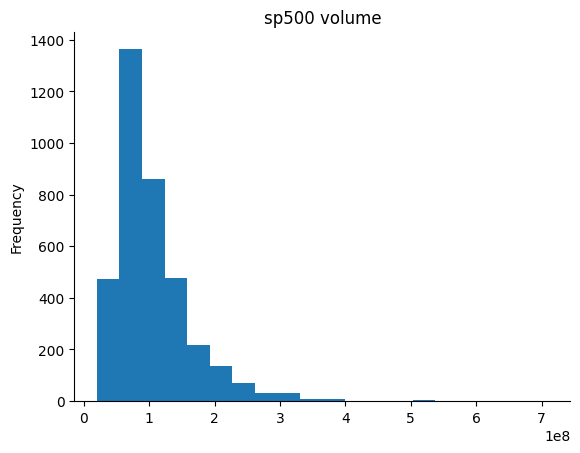

In [125]:
_df_3['sp500 volume'].plot(kind='hist', bins=20, title='sp500 volume')
plt.gca().spines[['top', 'right',]].set_visible(False)

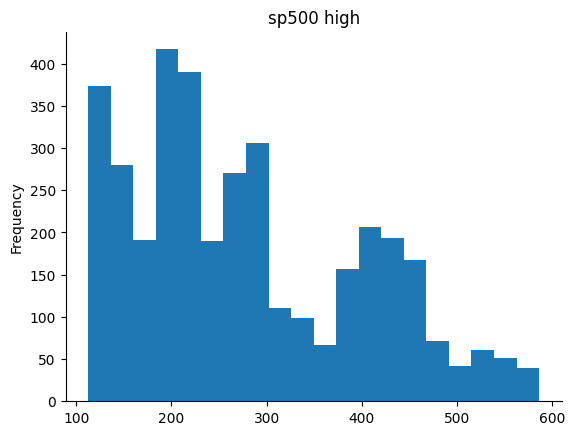

In [124]:
_df_1['sp500 high'].plot(kind='hist', bins=20, title='sp500 high')
plt.gca().spines[['top', 'right',]].set_visible(False)

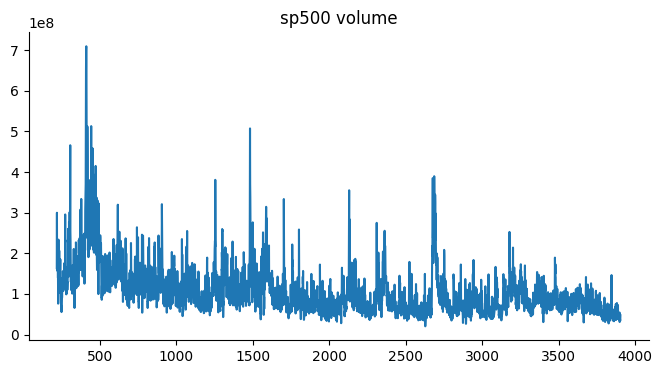

In [123]:
_df_11['sp500 volume'].plot(kind='line', figsize=(8, 4), title='sp500 volume')
plt.gca().spines[['top', 'right']].set_visible(False)

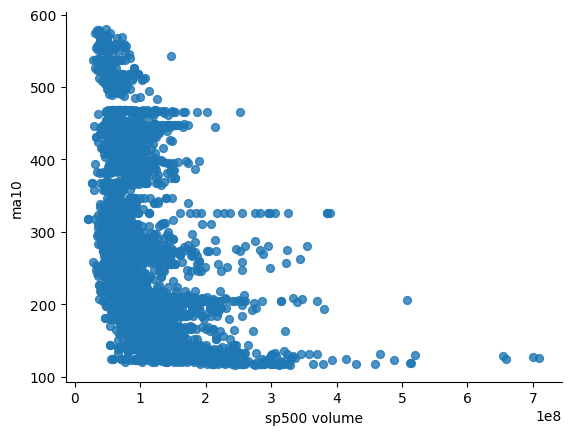

In [122]:
_df_7.plot(kind='scatter', x='sp500 volume', y='ma10', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

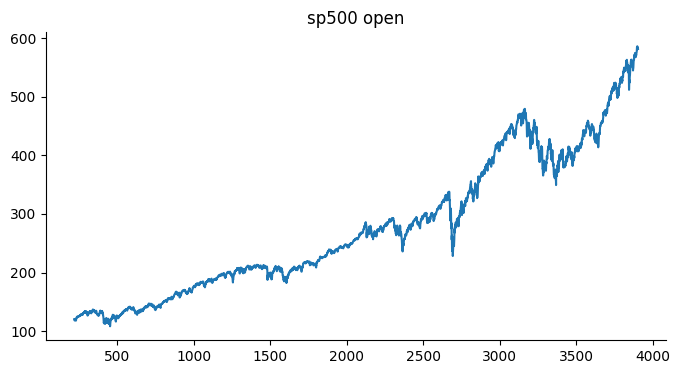

In [121]:
_df_8['sp500 open'].plot(kind='line', figsize=(8, 4), title='sp500 open')
plt.gca().spines[['top', 'right']].set_visible(False)

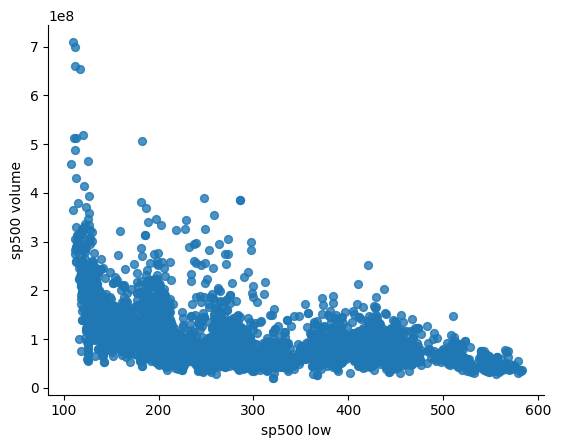

In [120]:
_df_6.plot(kind='scatter', x='sp500 low', y='sp500 volume', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

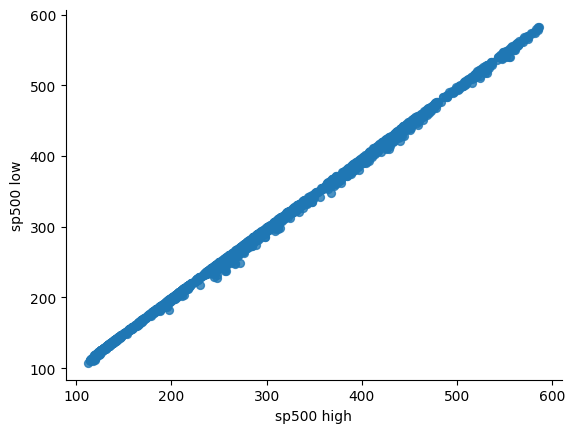

In [119]:
_df_5.plot(kind='scatter', x='sp500 high', y='sp500 low', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

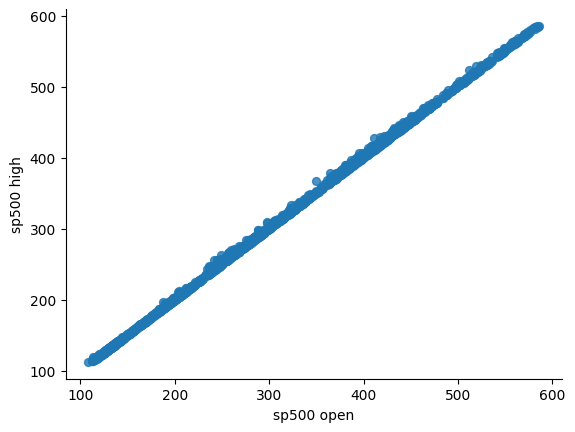

In [118]:
_df_4.plot(kind='scatter', x='sp500 open', y='sp500 high', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

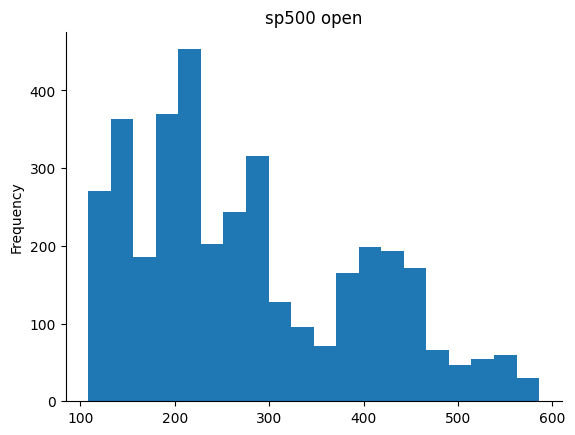

In [117]:
_df_0['sp500 open'].plot(kind='hist', bins=20, title='sp500 open')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [45]:
target

,sp500 close
0,114.93
1,113.64
2,113.64
3,115.06
4,113.89
...,...
3899,582.35
3900,584.59
3901,583.63
3902,583.32


from matplotlib import pyplot as plt
_df_12['sp500 close'].plot(kind='hist', bins=20, title='sp500 close')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_13['sp500 close'].plot(kind='line', figsize=(8, 4), title='sp500 close')
plt.gca().spines[['top', 'right']].set_visible(False)

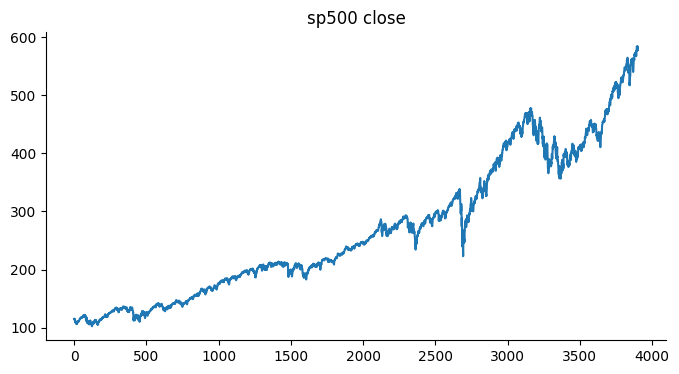

In [126]:

_df_13['sp500 close'].plot(kind='line', figsize=(8, 4), title='sp500 close')
plt.gca().spines[['top', 'right']].set_visible(False)

In [46]:
features.dropna(inplace=True)
target.dropna(inplace=True)

<ipython-input-46-82148a288311>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features.dropna(inplace=True)
<ipython-input-46-82148a288311>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target.dropna(inplace=True)


In [47]:
features.isnull().sum()

,0
sp500 open,0
sp500 high,0
sp500 low,0
sp500 volume,0
ma10,0
ma50,0
RSI,0
MACD,0
signal_line,0
ATR_14,0


In [48]:
target.isnull().sum()

,0
sp500 close,0


In [59]:
print('features', features.shape)
print('target', target.shape)

features (3685, 10)
target (3685, 1)


In [56]:
features, target = features.align(target, join='inner', axis=0)

In [62]:
features, target.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3685 entries, 219 to 3903
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sp500 close  3685 non-null   float64
dtypes: float64(1)
memory usage: 57.6 KB


(      sp500 open  sp500 high  sp500 low  sp500 volume        ma10      ma50  \
 219       120.58    121.0500   119.9800   163635229.0  120.790833  116.5112   
 220       119.29    119.4900   117.5900   299705738.0  120.763333  116.6816   
 221       118.21    118.7100   117.8600   172013797.0  120.737500  116.8378   
 222       119.36    120.3900   119.3500   197429267.0  120.778333  117.0186   
 223       119.90    120.3400   119.2500   156802316.0  120.806667  117.1948   
 ...          ...         ...        ...           ...         ...       ...   
 3899      585.91    586.1200   582.1600    34393714.0  576.019167  451.2422   
 3900      584.07    585.3900   582.5800    37416801.0  577.330000  451.2422   
 3901      583.85    584.8500   580.6001    36439010.0  578.647500  451.2422   
 3902      581.05    584.5000   580.3800    34183835.0  579.509167  451.2422   
 3903      581.26    581.7086   574.4150    47444991.0  580.358333  451.2422   
 
             RSI      MACD  signal_lin

In [ ]:
df_combined = pd.concat([features, target], axis=1)


scaler = MinMaxScaler()
dfs = scaler.fit_transform(df_combined)

In [ ]:
x = dfs[:, :-1]  
y = dfs[:, -1]

In [78]:
print('x', x.shape)
print('y', y.shape)

x (3685, 10)
y (3685,)


In [ ]:
def create_sequence(data, time_steps=30):
  x,y= [],[]
  for i in range(len(data)- time_steps):
    x.append(data[i:i+time_steps,:-1]) 
    y.append(data[i+time_steps, -1]) 
  return np.array(x), np.array(y)

time_steps=30
x,y=create_sequence(dfs, time_steps)

x = x.reshape(x.shape[0], time_steps, features.shape[1]) 

In [87]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model= Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2]))),
model.add(LSTM(units=50, return_sequences=True)),
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True)),
model.add(Dropout(0.2))
model.add(LSTM(units=50)),
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
LSTM= model.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - loss: 0.0181 - val_loss: 8.4143e-04
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0027 - val_loss: 3.8052e-04
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0022 - val_loss: 6.2056e-04
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0019 - val_loss: 0.0012
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0017 - val_loss: 4.7079e-04
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 0.0016 - val_loss: 4.2479e-04
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0016 - val_loss: 6.2617e-04
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0014 - val_loss: 6.7357e-04
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0014 - val_loss: 4.3994e-04
Epoch 10/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0017 - val_loss: 5.4469e-04
Epoch 11/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0014 - val_loss: 3.0635e-04
Epoch 12/50
92/92 ━━━━━━━━━━━━━━━━

In [106]:
LSTM

In [108]:
predictions = model.predict(x_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [110]:
loss=LSTM.history['loss']
val=LSTM.history['val_loss']

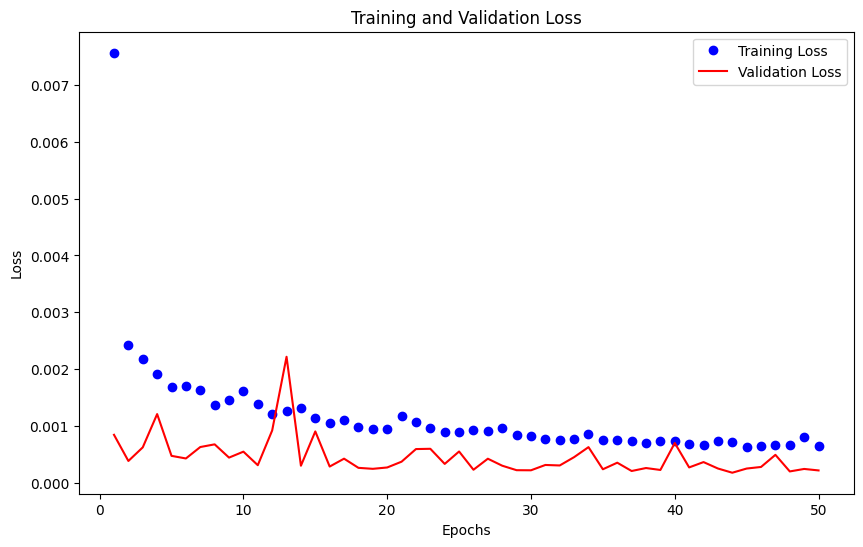

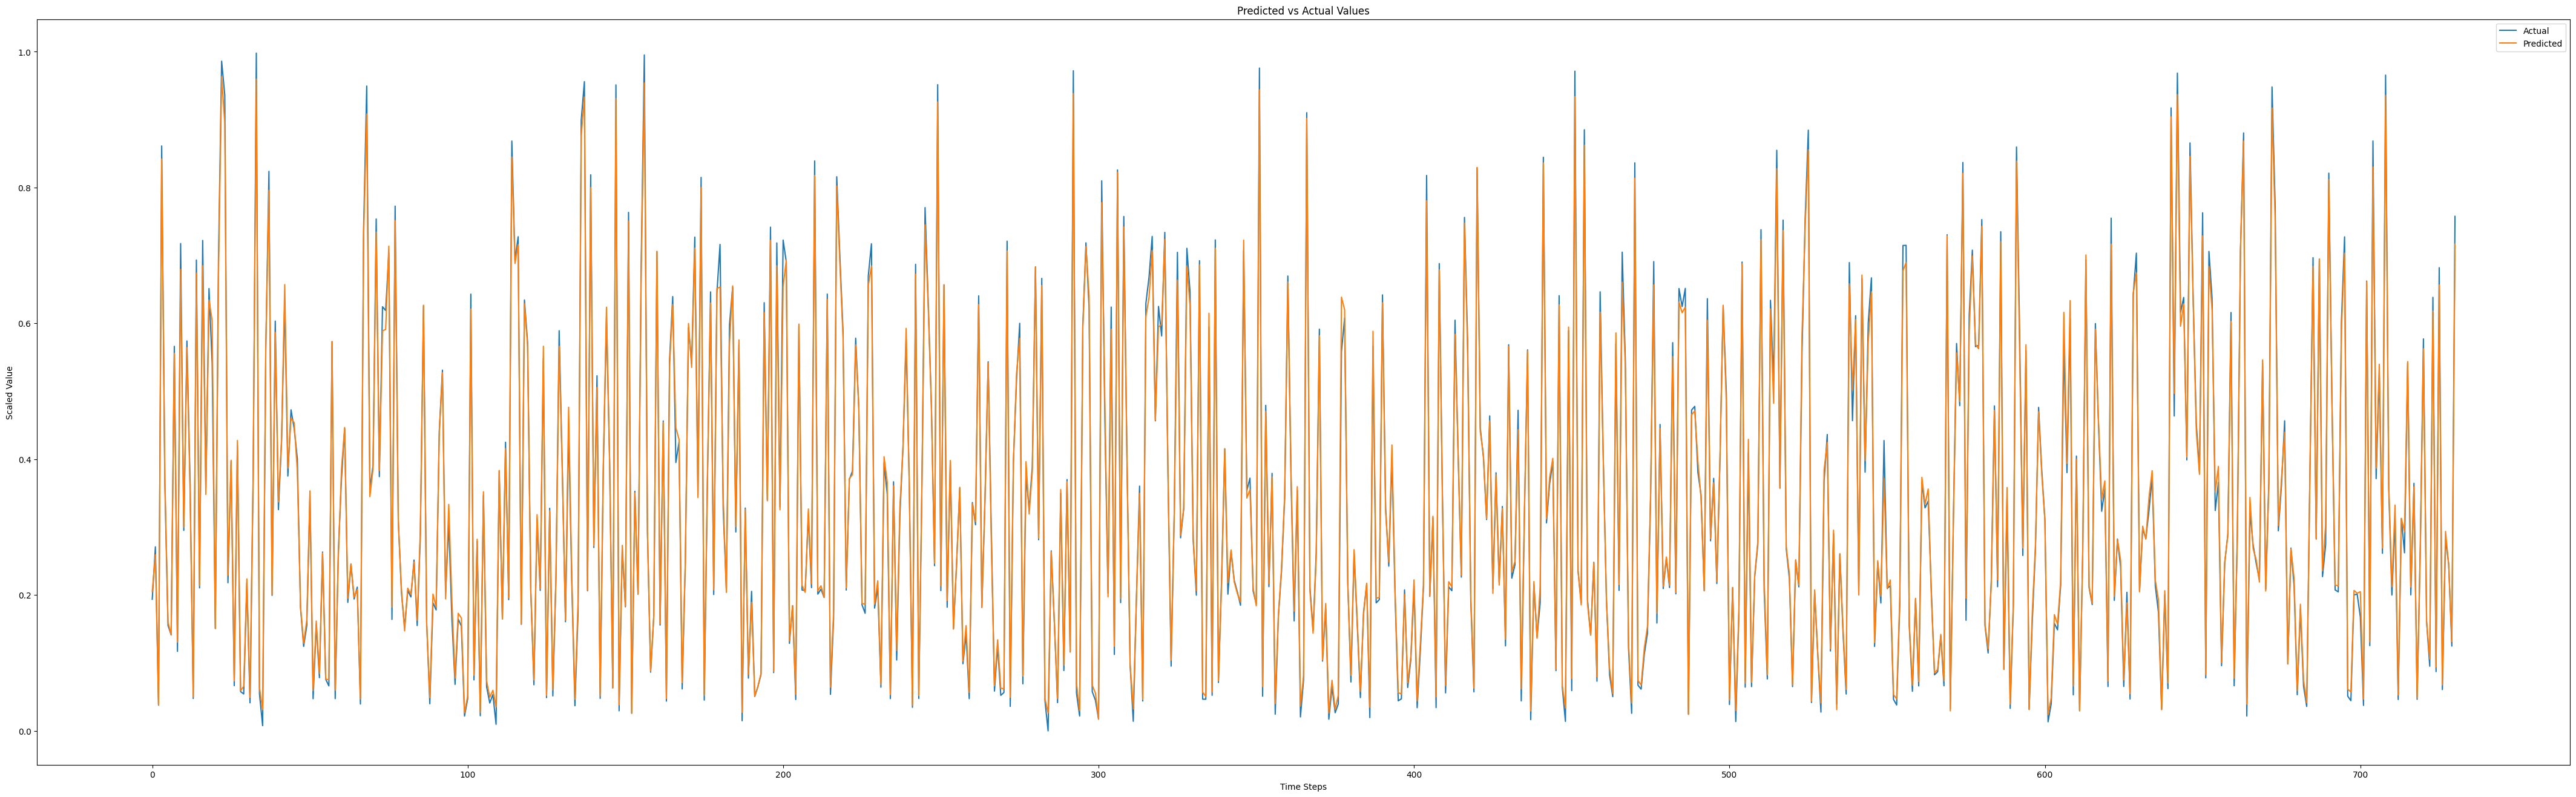

In [116]:


import matplotlib.pyplot as plt


loss = LSTM.history['loss']
val_loss = LSTM.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Plot predicted vs actual values
plt.figure(figsize=(54, 16))
plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')
plt.title('Predicted vs Actual Values')
plt.xlabel('Time Steps')
plt.ylabel('Scaled Value')
plt.legend()
plt.show()

The model has been properly trained predictions are accurate based on the diagram above